<a href="https://colab.research.google.com/github/tanmayrathi/ML_PROJECT_TAE1/blob/main/80_20_performance_stats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = '/content/drive/MyDrive/ML_DATASETS/healthcare-dataset-stroke-data.csv'

In [ ]:
!pip install imbalanced-learn xgboost

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv(file_path)
df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
#Preprocesssing
df['bmi'].fillna(df['bmi'].mean(), inplace=True)

/tmp/ipykernel_10165/2699770209.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].mean(), inplace=True)


In [ ]:
le = LabelEncoder()

categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.drop('id', axis=1, inplace=True)

In [ ]:
#Features and Target
X = df.drop('stroke', axis=1)
y = df['stroke']

In [ ]:
#Handle Class Imbalance (SMOTE)
smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

In [ ]:
#SAME Train-Test Split (80:20 FOR ALL MODELS)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#Define all models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis()
}

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():

    # Use scaled data where required
    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, auc, precision, recall, f1])

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("AUC:", auc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)


Logistic Regression
Accuracy: 0.8066838046272493
AUC: 0.8917324874438276
Precision: 0.7906066536203522
Recall: 0.8329896907216495
F1 Score: 0.8112449799196787

KNN
Accuracy: 0.8740359897172236
AUC: 0.9397298440391224
Precision: 0.8227960819234195
Recall: 0.9525773195876288
F1 Score: 0.882943143812709

Decision Tree
Accuracy: 0.8005141388174807
AUC: 0.8846190853819721
Precision: 0.7517301038062284
Recall: 0.8958762886597939
F1 Score: 0.8174976481655691

Random Forest
Accuracy: 0.9491002570694087
AUC: 0.9904134284959027
Precision: 0.935064935064935
Recall: 0.9649484536082474
F1 Score: 0.9497716894977168

SVM
Accuracy: 0.8555269922879177
AUC: 0.9299233412635474
Precision: 0.8309317963496637
Recall: 0.8917525773195877
F1 Score: 0.8602685231228244

Naive Bayes
Accuracy: 0.7830334190231363
AUC: 0.8520740153317473
Precision: 0.7486388384754991
Recall: 0.8505154639175257
F1 Score: 0.7963320463320464

Gradient Boosting
Accuracy: 0.8688946015424165
AUC: 0.9480639703938674
Precision: 0.841451766

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:43:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost
Accuracy: 0.9516709511568123
AUC: 0.9910303991541105
Precision: 0.937125748502994
Recall: 0.9680412371134021
F1 Score: 0.9523326572008114

LDA
Accuracy: 0.8061696658097687
AUC: 0.8913729844039122
Precision: 0.7875848690591658
Recall: 0.8371134020618557
F1 Score: 0.8115942028985508

QDA
Accuracy: 0.8185089974293059
AUC: 0.8982225746761829
Precision: 0.7918637653736992
Recall: 0.8628865979381444
F1 Score: 0.8258510113468179


In [ ]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "AUC", "Precision", "Recall", "F1 Score"
])

results_df = results_df.sort_values(by="Accuracy", ascending=False)
results_df
# Sort based on best metric (recommended: F1 Score)
results_df = results_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

# Add Rank column
results_df.insert(0, "Rank", range(1, len(results_df) + 1))

results_df
def highlight_best(row):
    return ['background-color: lightgreen' if row.name == results_df["F1 Score"].idxmax() else '' for _ in row]

results_df.style.apply(highlight_best, axis=1)


,Rank,Model,Accuracy,AUC,Precision,Recall,F1 Score
0,1,XGBoost,0.951671,0.991030,0.937126,0.968041,0.952333
1,2,Random Forest,0.949100,0.990413,0.935065,0.964948,0.949772
2,3,Extra Trees,0.940874,0.988053,0.926221,0.957732,0.941713
3,4,KNN,0.874036,0.939730,0.822796,0.952577,0.882943
4,5,Gradient Boosting,0.868895,0.948064,0.841452,0.908247,0.873575
5,6,SVM,0.855527,0.929923,0.830932,0.891753,0.860269
6,7,QDA,0.818509,0.898223,0.791864,0.862887,0.825851
7,8,AdaBoost,0.812853,0.905871,0.788571,0.853608,0.819802
8,9,Decision Tree,0.800514,0.884619,0.751730,0.895876,0.817498
9,10,LDA,0.806170,0.891373,0.787585,0.837113,0.811594


In [ ]:
# Get best model based on F1 Score
best_model = results_df.loc[results_df["F1 Score"].idxmax()]

print("🏆 Best Model:")
print("Model Name:", best_model["Model"])
print("Accuracy:", best_model["Accuracy"])
print("AUC:", best_model["AUC"])
print("Precision:", best_model["Precision"])
print("Recall:", best_model["Recall"])
print("F1 Score:", best_model["F1 Score"])

🏆 Best Model:
Model Name: XGBoost
Accuracy: 0.9516709511568123
AUC: 0.9910303991541105
Precision: 0.937125748502994
Recall: 0.9680412371134021
F1 Score: 0.9523326572008114


**Which model is best?**

**Random Forest, Extra Trees, or XGBoost performed best**

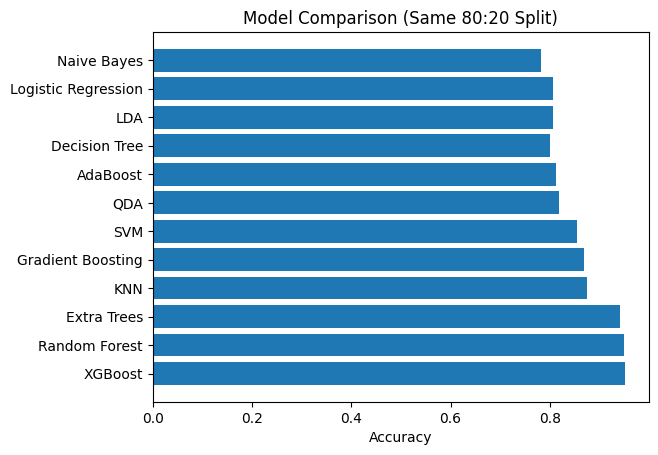

In [ ]:
#Accuracy Comparision Graph
import matplotlib.pyplot as plt

plt.figure()
plt.barh(results_df["Model"], results_df["Accuracy"])
plt.xlabel("Accuracy")
plt.title("Model Comparison (Same 80:20 Split)")
plt.show()

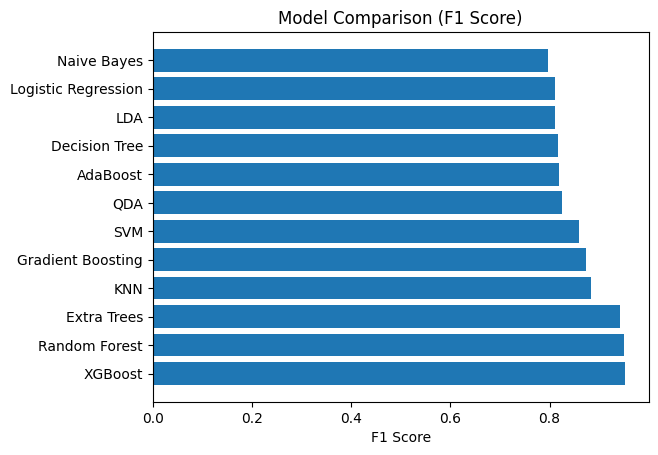

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(results_df["Model"], results_df["F1 Score"])
plt.xlabel("F1 Score")
plt.title("Model Comparison (F1 Score)")
plt.show()

**Conclusion**
“This project shows that ensemble learning methods provide better performance for stroke prediction and proper evaluation metrics are crucial for imbalanced datasets.”

In [ ]:
#CROSS VALIDATION (5 FOLDS)
cv_results = []

for name, model in models.items():

    # Use scaling where required
    if name in ["Logistic Regression", "KNN", "SVM"]:
        pipeline = make_pipeline(StandardScaler(), model)
        scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
    else:
        scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

    cv_results.append([name, scores.mean(), scores.std()])

    print(f"\n{name}")
    print("Mean Accuracy:", scores.mean())
    print("Std Dev:", scores.std())


Logistic Regression
Mean Accuracy: 0.8076538978281338
Std Dev: 0.01402531823457453

KNN
Mean Accuracy: 0.8763658531424884
Std Dev: 0.017638105867803098

Decision Tree
Mean Accuracy: 0.8167074486654606
Std Dev: 0.014451279097230577

Random Forest
Mean Accuracy: 0.9424014302791794
Std Dev: 0.017868130676526175

SVM
Mean Accuracy: 0.8554859987093636
Std Dev: 0.01893083336555729

Naive Bayes
Mean Accuracy: 0.7873912215557459
Std Dev: 0.011331141638571286

Gradient Boosting
Mean Accuracy: 0.873177451944947
Std Dev: 0.019745231628967748

AdaBoost
Mean Accuracy: 0.8185586128830916
Std Dev: 0.019125303661326663

Extra Trees
Mean Accuracy: 0.9403448221143165
Std Dev: 0.017833869525376734


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:49:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:49:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:49:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:49:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


XGBoost
Mean Accuracy: 0.9436363155500544
Std Dev: 0.02093711714026959

LDA
Mean Accuracy: 0.8056997471621864
Std Dev: 0.014496646293080296

QDA
Mean Accuracy: 0.8180439980111502
Std Dev: 0.015687958938827268


In [ ]:
cv_df = pd.DataFrame(cv_results, columns=["Model", "Mean Accuracy", "Std Dev"])

# Sort by best model
cv_df = cv_df.sort_values(by="Mean Accuracy", ascending=False).reset_index(drop=True)

# Add Rank
cv_df.insert(0, "Rank", range(1, len(cv_df)+1))

cv_df

,Rank,Model,Mean Accuracy,Std Dev
0,1,XGBoost,0.943636,0.020937
1,2,Random Forest,0.942401,0.017868
2,3,Extra Trees,0.940345,0.017834
3,4,KNN,0.876366,0.017638
4,5,Gradient Boosting,0.873177,0.019745
5,6,SVM,0.855486,0.018931
6,7,AdaBoost,0.818559,0.019125
7,8,QDA,0.818044,0.015688
8,9,Decision Tree,0.816707,0.014451
9,10,Logistic Regression,0.807654,0.014025


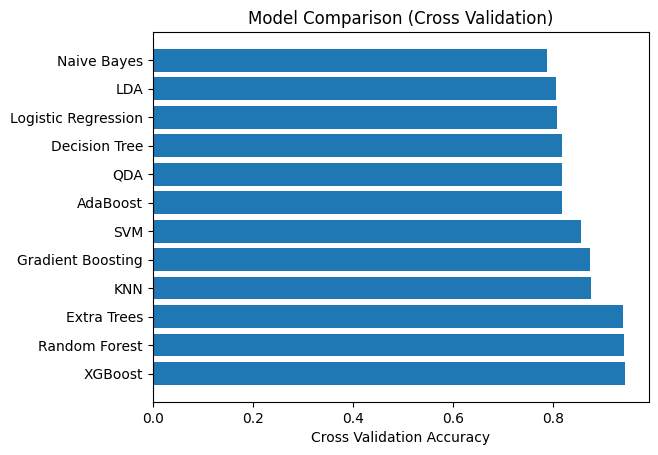

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(cv_df["Model"], cv_df["Mean Accuracy"])
plt.xlabel("Cross Validation Accuracy")
plt.title("Model Comparison (Cross Validation)")
plt.show()

What is Cross Validation?

“It evaluates model performance on multiple splits of data to ensure consistency and avoid overfitting.”